# DNA Fiber Assay Analysis of ORC1 mutants


**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-08-17

## Workflow
1. Parameters import
2. Data loading
3. Data propcessing
4. Basic statistics calculation
5. Processing outliers
6. Statistical analysis
7. Tables export
8. Graphs plot

# 1. Parameters

In [29]:
INPUT_DIR = "/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZED"
OUTPUT_DIR = "/mnt/c/users/helen/Desktop/290925_GOOD/RESULTS"

pixel_size = 0.16125 # µm
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 2. Import data

## 2.1 Data loading

In [30]:
from utils import load_data, data_subset

data = load_data(dir = INPUT_DIR, pixel_size=pixel_size)

print(f"Total number of measurements for analysis is: {data.shape[0]}")

Total number of measurements for analysis is: 1415


In [31]:
data

,Sample_name,File,Measurement_type,Length,ROI,Path
0,None,MGS1_5-02_Fiber_length,Fiber_length,8.249066,0576-0284,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
1,None,MGS1_5-02_Fiber_length,Fiber_length,6.534656,0582-0336,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
2,None,MGS1_5-02_Fiber_length,Fiber_length,3.562174,0541-0074,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
3,None,MGS1_5-02_Fiber_length,Fiber_length,5.344470,0537-0044,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
4,None,MGS1_5-02_Fiber_length,Fiber_length,4.150414,0615-0480,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
...,...,...,...,...,...,...
1410,None,WT6-05_Interorigin_distance,Interorigin_distance,26.806845,0161-0369,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
1411,None,WT6-05_Interorigin_distance,Interorigin_distance,17.924873,0145-0611,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
1412,None,WT6-10_Interorigin_distance,Interorigin_distance,13.701251,0691-0712,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
1413,None,WT6-10_Interorigin_distance,Interorigin_distance,22.469059,0699-0866,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...


In [32]:
# Sample name 29.09.25
data['Sample_name'] = data['File'].apply(lambda x: x.split('_')[1] if 'siORC1_MGS' in x else x.split('-')[0])
data['Sample_name'] = data['Sample_name'].apply(lambda x: 'WT' if 'WT' in x else x)
data['Sample_name'] = data['Sample_name'].apply(lambda x: 'siSCR' if 'siSCR' in x else x)
data['Sample_name'] = data['Sample_name'].apply(lambda x: x.split('-')[0] if 'MGS' in x else x)
data['Sample_name'] = data['Sample_name'].apply(lambda x: 'siORC1' if 'siORC1' in x else x)
data['Sample_name'] = data['Sample_name'].apply(lambda x: x.split('_')[0] if 'MGS' in x else x)

In [33]:
# Check sample names
data['Sample_name'].unique()

<StringArray>
['MGS1', 'MGS2', 'MGS5', 'siORC1', 'MGS3', 'MGS4', 'WT', 'siSCR']
Length: 8, dtype: str

### 2.3 Split data into replication speed and IOD dataframe

In [34]:
speed = data_subset(df = data, measurement_type = 'Fiber_length')
print(f"The total amount of fibers measurements is: {speed.shape[0]}")

iod = data_subset(df = data, measurement_type = 'Interorigin_distance')
print(f"The total amount of IOD measurements is: {iod.shape[0]}")

The total amount of fibers measurements is: 916
The total amount of IOD measurements is: 499


### 2.4 Checking the number of measurements for each sample

#### 2.4.1 Replication speed
Divide this number by 2 because these are green and red tracks separately.

In [35]:
speed.groupby('Sample_name')['File'].count()

Sample_name
MGS1       98
MGS2       96
MGS3      106
MGS4       96
MGS5       98
WT        154
siORC1    152
siSCR     116
Name: File, dtype: int64

In [36]:
# OPTIONAL
# Check analized files
sample_name = "MGS4"
speed[speed["Sample_name"] == sample_name]['File'].value_counts()

File
siORC1_MGS4-17_Fiber_length    12
siORC1_MGS4-07_Fiber_length    10
siORC1_MGS4-30_Fiber_length    10
siORC1_MGS4-14_Fiber_length     8
siORC1_MGS4-02_Fiber_length     6
siORC1_MGS4-05_Fiber_length     6
siORC1_MGS4-15_Fiber_length     6
siORC1_MGS4-16_Fiber_length     6
siORC1_MGS4-06_Fiber_length     4
siORC1_MGS4-10_Fiber_length     4
siORC1_MGS4-12_Fiber_length     4
siORC1_MGS4-22_Fiber_length     4
siORC1_MGS4-34_Fiber_length     4
siORC1_MGS4-24_Fiber_length     2
siORC1_MGS4-25_Fiber_length     2
siORC1_MGS4-28_Fiber_length     2
siORC1_MGS4-37_Fiber_length     2
siORC1_MGS4-38_Fiber_length     2
siORC1_MGS4-39_Fiber_length     2
Name: count, dtype: int64

#### 2.4.2. IOD

In [37]:
iod.groupby('Sample_name')['File'].count()

Sample_name
MGS1       27
MGS2       39
MGS3       35
MGS4       35
MGS5       40
WT        120
siORC1     93
siSCR     110
Name: File, dtype: int64

In [38]:
# OPTIONAL
# Check analized files
sample_name = "MGS3"
iod[iod["Sample_name"] == sample_name]['File'].value_counts()

File
siORC1_MGS3-20_Interorigin_distance    5
siORC1_MGS3-37_Interorigin_distance    4
siORC1_MGS3-02_Interorigin_distance    3
siORC1_MGS3-04_Interorigin_distance    3
siORC1_MGS3-21_Interorigin_distance    3
siORC1_MGS3-29_Interorigin_distance    3
siORC1_MGS3-15_Interorigin_distance    2
siORC1_MGS3-22_Interorigin_distance    2
siORC1_MGS3-39_Interorigin_distance    2
siORC1_MGS3-03_Interorigin_distance    1
siORC1_MGS3-05_Interorigin_distance    1
siORC1_MGS3-19_Interorigin_distance    1
siORC1_MGS3-23_Interorigin_distance    1
siORC1_MGS3-27_Interorigin_distance    1
siORC1_MGS3-33_Interorigin_distance    1
siORC1_MGS3-38_Interorigin_distance    1
siORC1_MGS3-40_Interorigin_distance    1
Name: count, dtype: int64

# 3. Data processing

In [39]:
from utils import speed_processing, iod_processing

replication_speed = speed_processing(df = speed, conversion_factor = conversion_factor, time = time)
iod_kb = iod_processing(df = iod, conversion_factor = conversion_factor)

All files contain an even number of fibers.


In [40]:
replication_speed.head()

,Sample_name,File,Speed_kb_min,ROI,Path
0,MGS1,MGS1_5-02_Fiber_length,1.914492,"[0576-0284, 0582-0336]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
1,MGS1,MGS1_5-02_Fiber_length,1.153410,"[0541-0074, 0537-0044]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
2,MGS1,MGS1_5-02_Fiber_length,1.854352,"[0615-0480, 0603-0429]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
3,MGS1,MGS1_5-02_Fiber_length,1.238400,"[0568-0298, 0567-0264]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
4,MGS2,MGS2_2-02_Fiber_length,1.559062,"[0059-0813, 0069-0858]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...


In [41]:
iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
8,MGS1,MGS1_5-02_Interorigin_distance,86.108500,0693-0558,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
15,MGS2,MGS2_2_Interorigin_distance,42.967799,0749-0104,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
16,MGS2,MGS2_2_Interorigin_distance,40.690422,0814-0290,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
17,MGS2,MGS2_2_Interorigin_distance,48.060471,0260-0266,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
18,MGS2,MGS2_2_Interorigin_distance,50.506573,0423-0572,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...


# 4. Basic statistics calculation

In [42]:
from utils import description_stats

stats_speed = description_stats(replication_speed, col = "Speed_kb_min")
stats_iod = description_stats(iod_kb, col = "IOD_kb")

In [43]:
stats_speed

,Count,Mean,Median,SD
Sample_name,,,,
MGS1,49,1.806583,1.729416,0.525473
MGS2,48,1.749556,1.730523,0.438837
MGS3,53,1.663987,1.562069,0.493414
MGS4,48,2.098554,1.970194,0.683546
MGS5,49,1.996494,2.082403,0.710489
WT,77,1.405830,1.404745,0.312272
siORC1,76,1.651857,1.515920,0.591919
siSCR,58,1.376885,1.349982,0.445264


In [44]:
stats_iod

,Count,Mean,Median,SD
Sample_name,,,,
MGS1,27,50.191118,46.260035,18.817651
MGS2,39,43.949451,44.531016,11.988720
MGS3,35,47.160581,44.718535,13.991852
MGS4,35,62.626306,62.018751,18.861275
MGS5,40,63.725698,60.093651,25.581089
WT,120,41.212308,40.671628,15.052449
siORC1,93,46.321334,45.044710,15.932851
siSCR,110,38.673214,35.308954,13.847129


# 5. Processing outliers

In [45]:
from utils import outliers

speed_outliers = outliers(df = replication_speed, col = 'Speed_kb_min')
iod_outliers = outliers(df = iod_kb, col = 'IOD_kb')

In [46]:
speed_outliers

,Sample_name,File,Speed_kb_min,ROI,Path
18,MGS5,MGS5_5-11_Fiber_length,3.516257,"[0747-0259, 0810-0193]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
21,MGS5,MGS5_5-12_Fiber_length,3.361877,"[0668-0580, 0694-0671]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
22,MGS5,MGS5_5-12_Fiber_length,3.278496,"[0733-0758, 0705-0677]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
127,siORC1,siORC1-16_Fiber_length,3.220591,"[0632-1239, 0621-1152]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
153,siORC1,siORC1_6-09_Fiber_length,3.453946,"[0335-1151, 0370-1075]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
188,MGS1,siORC1_MGS1-20_Fiber_length,3.346550,"[0877-1008, 0935-0958]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
219,MGS1,siORC1_MGS1-36_Fiber_length,3.957241,"[0765-0175, 0787-0081]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
312,MGS4,siORC1_MGS4-05_Fiber_length,3.137564,"[0143-0701, 0208-0657]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
321,MGS4,siORC1_MGS4-07_Fiber_length,3.105740,"[0172-0734, 0230-0685]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
330,MGS4,siORC1_MGS4-15_Fiber_length,3.099977,"[0811-0477, 0767-0547]",/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...


In [47]:
iod_outliers

,Sample_name,File,IOD_kb,ROI,Path
58,MGS5,MGS5_5-07_Interorigin_distance,113.733132,0341-0823,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
60,MGS5,MGS5_5-07_Interorigin_distance,121.273995,0649-0368,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
63,MGS5,MGS5_5-08_Interorigin_distance,91.213283,0578-0391,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
64,MGS5,MGS5_5-09_Interorigin_distance,108.715635,0505-0256,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
144,MGS5,MGS5_5-18_Interorigin_distance,121.031348,0452-0458,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
145,MGS5,MGS5_5-18_Interorigin_distance,87.385218,0133-1124,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
154,MGS5,MGS5_5-25_Interorigin_distance,92.926850,0574-1106,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
157,MGS5,MGS5_5-26_Interorigin_distance,90.447753,0764-0284,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
334,siORC1,siORC1_5-06_Interorigin_distance,103.518972,0621-0530,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...
336,siORC1,siORC1_5-08_Interorigin_distance,88.952193,0532-0412,/mnt/c/users/helen/Desktop/290925_GOOD/ANALYZE...


In [48]:
# Delete ouliers from the dataframes
speed_clean = replication_speed.drop(index=speed_outliers.index)
iod_kb_clean = iod_kb.drop(index=iod_outliers.index)

# 6. Statistical analysis
Mann-Whetney test (U-test)

In [49]:
from utils import u_test

u_speed = u_test(df = replication_speed, col = "Speed_kb_min", control_sample = "WT")
u_iod = u_test(df = iod_kb, col = "IOD_kb", control_sample = "WT")

In [50]:
u_speed


,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,WT,MGS3,77,53,1454.0,5.497831e-03
1,WT,MGS2,77,48,1000.0,1.691977e-05
2,WT,MGS5,77,49,938.0,2.094369e-06
3,WT,MGS1,77,49,890.0,6.218460e-07
4,WT,siORC1,77,76,2289.0,2.020005e-02
5,WT,MGS4,77,48,676.0,2.734734e-09
6,WT,siSCR,77,58,2471.0,2.911221e-01


In [51]:
u_iod

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,WT,MGS3,120,35,1566.0,2.242040e-02
1,WT,MGS2,120,39,1988.5,1.599839e-01
2,WT,MGS5,120,40,1091.0,2.519951e-07
3,WT,MGS1,120,27,1151.0,1.909495e-02
4,WT,siORC1,120,93,4600.0,2.811955e-02
5,WT,MGS4,120,35,799.5,2.644307e-08
6,WT,siSCR,120,110,7195.5,2.378568e-01


# 7. Tables export

In [52]:
from utils import table_export


# Export of tables with processed results
table_export(df = speed_clean, dir = OUTPUT_DIR, filename = "replication_speed.xlsx")
table_export(df = iod_kb_clean, dir = OUTPUT_DIR, filename = "iod_kb.xlsx")

# Export of tables with descriptive statistics
table_export(df = stats_speed, dir = OUTPUT_DIR, filename = "replication_speed_description.xlsx")
table_export(df = stats_iod, dir = OUTPUT_DIR, filename = "iod_description.xlsx")

# Export of tables with U-test analysis
table_export(df = u_speed, dir = OUTPUT_DIR, filename = "u_speed.xlsx")
table_export(df = u_iod, dir = OUTPUT_DIR, filename = "u_iod.xlsx")

# 8. Graphs with statistics

In [53]:
from plotting import boxplot_with_statistics

### 8.1 IOD graph

Plot saved to: /mnt/c/users/helen/Desktop/290925_GOOD/RESULTS/IOD_kb.png


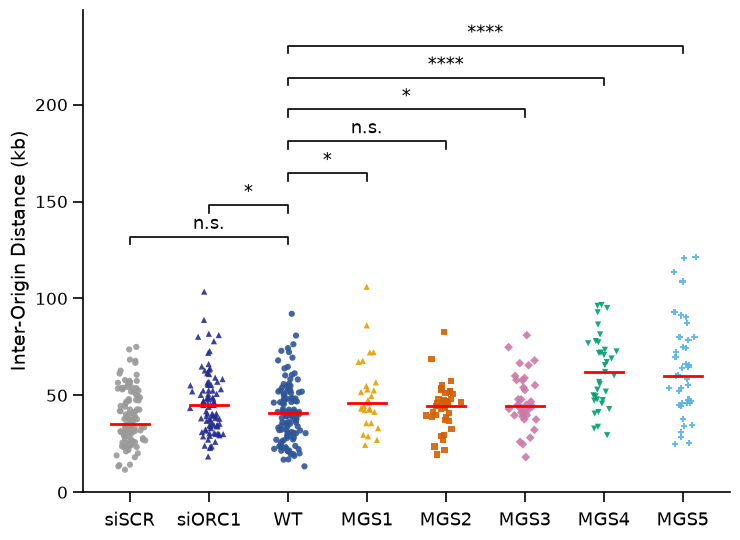

(<Figure size 750x550 with 1 Axes>,
 <Axes: ylabel='Inter-Origin Distance (kb)'>)

In [56]:
boxplot_with_statistics(
        data = iod_kb,
        var = "IOD_kb",
        sample_order = ['siSCR', 'siORC1', 'WT', 'MGS1', 'MGS2', 'MGS3', 'MGS4', 'MGS5'],
        
        sample_labels={
        "siSCR": "siSCR",
        "siORC1": "siORC1",
        "WT": "WT",
        "MGS1": "MGS1",
        "MGS2": "MGS2",
        "MGS3": "MGS3",
        "MGS4": "MGS4",
        "MGS5": "MGS5",
        },
        
        sample_colors={
        "siSCR": "#9A9A9A",   # gray
        "siORC1": "#252D8F",  # dark blue
        "WT": "#2F5597",      # blue
        "MGS1": "#E69F00",    # orange
        "MGS2": "#D55E00",    # vermillion
        "MGS3": "#CC79A7",    # purple/pink
        "MGS4": "#009E73",    # green
        "MGS5": "#56B4E9",    # light blue
        },
        
        sample_markers={
        "siSCR": "o",
        "siORC1": "^",
        "WT": "o",
        "MGS1": "^",
        "MGS2": "s",
        "MGS3": "D",
        "MGS4": "v",
        "MGS5": "P",
        },
    
        figsize = (7.5, 5.5),
        
        stats = [
                {
                "group1": "WT",
                "group2": "siSCR",
                "p_value": 2.378568e-01,
                },
                
                {
                "group1": "WT",
                "group2": "siORC1",
                "p_value": 2.811955e-02,
                },
                
                {
                "group1": "WT",
                "group2": "MGS1",
                "p_value": 1.909495e-02,
                },
                
                {
                "group1": "WT",
                "group2": "MGS2",
                "p_value": 1.599839e-01,
                },
                
                {
                "group1": "WT",
                "group2": "MGS3",
                "p_value": 2.242040e-02,
                },
                
                {
                "group1": "WT",
                "group2": "MGS4",
                "p_value": 2.644307e-08,
                },
                
                {
                "group1": "WT",
                "group2": "MGS5",
                "p_value": 2.519951e-07,
                }
        
        ],
        
        y_axis = "Inter-Origin Distance (kb)",
        save_dir = OUTPUT_DIR,
        save_name = "IOD_kb",
        ext = "png"
)
        

### 8.2 Replication speed graph

Plot saved to: /mnt/c/users/helen/Desktop/290925_GOOD/RESULTS/speed.png


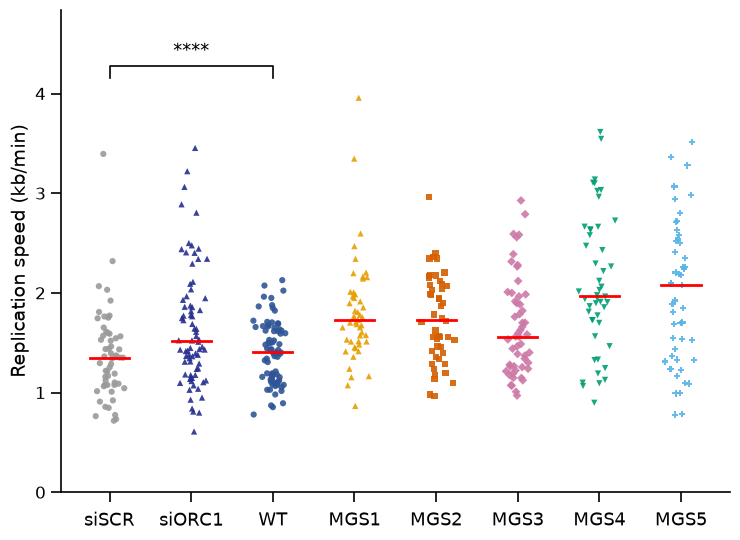

(<Figure size 750x550 with 1 Axes>,
 <Axes: ylabel='Replication speed (kb/min)'>)

In [ ]:
boxplot_with_statistics(
        data = replication_speed,
        var = "Speed_kb_min",
        sample_order = ['siSCR', 'siORC1', 'WT', 'MGS1', 'MGS2', 'MGS3', 'MGS4', 'MGS5'],
        
        sample_labels={
        "siSCR": "siSCR",
        "siORC1": "siORC1",
        "WT": "WT",
        "MGS1": "MGS1",
        "MGS2": "MGS2",
        "MGS3": "MGS3",
        "MGS4": "MGS4",
        "MGS5": "MGS5",
        },
        
        sample_colors={
        "siSCR": "#9A9A9A",   # gray
        "siORC1": "#252D8F",  # dark blue
        "WT": "#2F5597",      # blue
        "MGS1": "#E69F00",    # orange
        "MGS2": "#D55E00",    # vermillion
        "MGS3": "#CC79A7",    # purple/pink
        "MGS4": "#009E73",    # green
        "MGS5": "#56B4E9",    # light blue
        },
        
        sample_markers={
        "siSCR": "o",
        "siORC1": "^",
        "WT": "o",
        "MGS1": "^",
        "MGS2": "s",
        "MGS3": "D",
        "MGS4": "v",
        "MGS5": "P",
        },
    
        figsize = (7.5, 5.5),
        
        stats = [
                {
                "group1": "WT",
                "group2": "siSCR",
                "p_value": 2.911221e-01,
                },
                
                {
                "group1": "WT",
                "group2": "siORC1",
                "p_value": 2.020005e-02,
                },
                
                {
                "group1": "WT",
                "group2": "MGS1",
                "p_value": 6.218460e-07,
                },
                
                {
                "group1": "WT",
                "group2": "MGS2",
                "p_value": 1.691977e-05,
                },
                
                {
                "group1": "WT",
                "group2": "MGS3",
                "p_value": 5.497831e-03,
                },
                
                {
                "group1": "WT",
                "group2": "MGS4",
                "p_value": 2.734734e-09,
                },
                
                {
                "group1": "WT",
                "group2": "MGS5",
                "p_value": 2.094369e-06,
                }
        
        ],
        
        y_axis = "Replication speed (kb/min)",
        save_dir = OUTPUT_DIR,
        save_name = "speed",
        ext = "png"
)
       